# Sistema de Segmentación Inteligente para Personalización de Recomendaciones en E-commerce de Electrónica

Este análisis implementa un clustering K-Means para segmentar clientes de una plataforma de e-commerce de electrónica. 
El objetivo es identificar perfiles de usuarios para personalizar recomendaciones de productos basadas en su comportamiento de compra.

**Fases del análisis:**
1. Carga y exploración de datos
2. Preprocesamiento (eliminación de variables no relevantes, escalado)
3. Determinación del número óptimo de clusters (Método del Codo + Silueta)
4. Entrenamiento del modelo K-Means
5. Análisis e interpretación de segmentos
6. Visualización con PCA

In [1]:
# Librerías básicas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Clustering
from sklearn.cluster import KMeans  # Algoritmo K-Means

# Preprocesamiento
from sklearn.preprocessing import StandardScaler  # Normalizar datos

# Reducción de dimensionalidad
from sklearn.decomposition import PCA  # Principal Component Analysis

# Métricas de evaluación
from sklearn.metrics import silhouette_score, silhouette_samples  # Coeficiente de silueta

# Configuración visual
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
np.random.seed(42)  # Reproducibilidad

print("✅ Librerías importadas correctamente")

from pathlib import Path

print("CWD:", Path.cwd())
print("Existe data/final:", (Path.cwd() / "data" / "final").exists())
print("Existe CSV:", (Path.cwd() / "data" / "final" / "user_clustering_dataset.csv").exists())

✅ Librerías importadas correctamente
CWD: C:\Users\juanp\DBS\PF_DATA_NOVA_ANALYTICS\notebooks
Existe data/final: True
Existe CSV: False


In [2]:
# Cargar el dataset
df = pd.read_csv('../data/final/user_clustering_dataset.csv')

print("=" * 80)
print("EXPLORACIÓN INICIAL DEL DATASET")
print("=" * 80)
print(f"\nDimensiones del dataset: {df.shape}")
print(f"\nPrimeras filas:")
print(df.head())
print(f"\nInformación del dataset:")
print(df.info())
print(f"\nEstadísticas descriptivas:")
print(df.describe())

EXPLORACIÓN INICIAL DEL DATASET

Dimensiones del dataset: (407237, 21)

Primeras filas:
               user_id  total_events  unique_products  view  cart  purchase  \
0  1515915625353226922             1                1     1     0         0   
1  1515915625353230067             1                1     1     0         0   
2  1515915625353230683            13               10    13     0         0   
3  1515915625353230922             1                1     1     0         0   
4  1515915625353234047            36                8    36     0         0   

    avg_price  avg_events_per_product  avg_purchase_price  weighted_score  \
0   76.480000                     1.0                 0.0               1   
1   28.980000                     1.0                 0.0               1   
2   62.686923                     1.3                 0.0              13   
3  274.400000                     1.0                 0.0               1   
4  152.275000                     4.5               

In [3]:
# Escalado de variables con StandardScaler

cluster_cols = [
    'total_events',
    'unique_products',
    'cart',
    'purchase',
    'avg_price',
    'avg_events_per_product',
    'avg_purchase_price',
    'recency_days',
    'pct_morning',
    'pct_evening',
    'proportion_tech',
    'proportion_fashion_lifestyle',
    'proportion_home'
]

df_clustering = df[cluster_cols]

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_clustering)

df_scaled = pd.DataFrame(df_scaled, columns=cluster_cols)

print("\n" + "=" * 80)
print("VARIABLES ESCALADAS")
print("=" * 80)
print(f"\nMedia de variables escaladas (debe ser ≈ 0):")
print(df_scaled.mean())
print(f"\nDesviación estándar escaladas (debe ser ≈ 1):")
print(df_scaled.std())


VARIABLES ESCALADAS

Media de variables escaladas (debe ser ≈ 0):
total_events                   -4.689993e-17
unique_products                 1.004999e-17
cart                           -8.933321e-18
purchase                       -3.238329e-17
avg_price                      -8.933321e-18
avg_events_per_product         -2.596246e-17
avg_purchase_price             -8.933321e-18
recency_days                    0.000000e+00
pct_morning                     1.228332e-17
pct_evening                     8.039989e-17
proportion_tech                -9.826653e-17
proportion_fashion_lifestyle   -4.857493e-17
proportion_home                -3.573328e-17
dtype: float64

Desviación estándar escaladas (debe ser ≈ 1):
total_events                    1.000001
unique_products                 1.000001
cart                            1.000001
purchase                        1.000001
avg_price                       1.000001
avg_events_per_product          1.000001
avg_purchase_price              1.000001

## Método del Codo para Determinar el Número Óptimo de Clusters

MÉTODO DEL CODO - Calculando inércias


K = 2: Inércia = 4515041.59


K = 3: Inércia = 3827129.06


K = 4: Inércia = 3389647.83


K = 5: Inércia = 3072037.16


K = 6: Inércia = 2803665.63


K = 7: Inércia = 2569349.88


K = 8: Inércia = 2409390.90


K = 9: Inércia = 2285351.06


K = 10: Inércia = 2178710.95


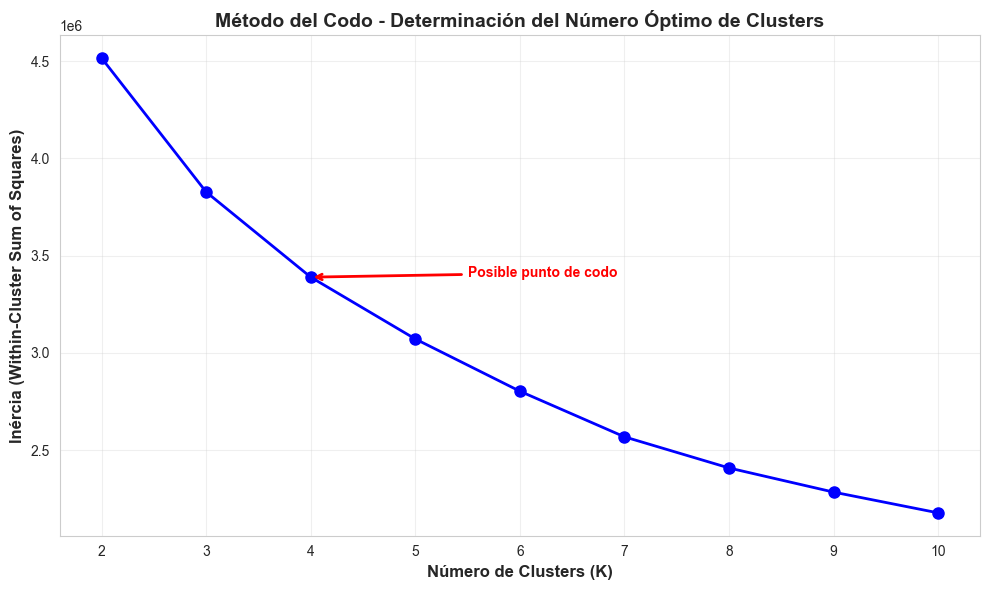


El punto del codo sugiere un número óptimo de clusters entre 3 y 5


In [4]:
# Aplicar el Método del Codo
inertias = []
k_range = range(2, 11)

print("=" * 80)
print("MÉTODO DEL CODO - Calculando inércias")
print("=" * 80)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    inertias.append(kmeans.inertia_)
    print(f"K = {k}: Inércia = {kmeans.inertia_:.2f}")

# Visualizar el método del codo
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
ax.set_xlabel('Número de Clusters (K)', fontsize=12, fontweight='bold')
ax.set_ylabel('Inércia (Within-Cluster Sum of Squares)', fontsize=12, fontweight='bold')
ax.set_title('Método del Codo - Determinación del Número Óptimo de Clusters', 
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_xticks(k_range)

# Anotación para el codo
ax.annotate('Posible punto de codo', xy=(4, inertias[2]), xytext=(5.5, inertias[2]+50),
            arrowprops=dict(arrowstyle='->', color='red', lw=2),
            fontsize=10, color='red', fontweight='bold')

plt.tight_layout()
plt.show()

print("\nEl punto del codo sugiere un número óptimo de clusters entre 3 y 5")

## Análisis de Silueta para Validar la Calidad de Clustering

ANÁLISIS DE SILUETA - Calculando scores


K = 2: Silhouette Score = 0.9741


K = 3: Silhouette Score = 0.3059


K = 4: Silhouette Score = 0.3320


K = 5: Silhouette Score = 0.2957


K = 6: Silhouette Score = 0.3064


K = 7: Silhouette Score = 0.3064


K = 8: Silhouette Score = 0.3372


K = 9: Silhouette Score = 0.3498


K = 10: Silhouette Score = 0.3550


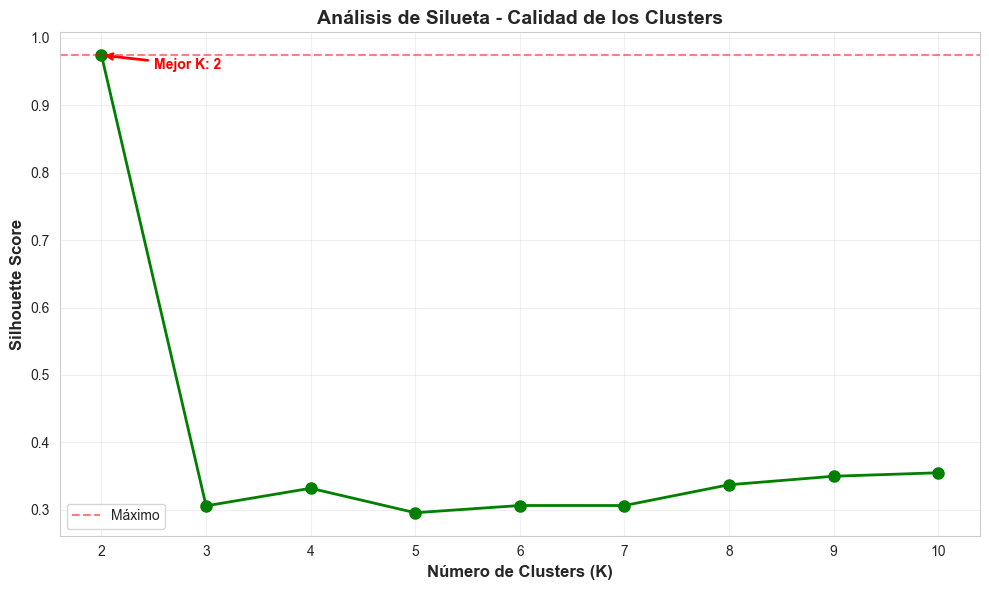


✓ Número óptimo de clusters según Silhouette Score: 2
✓ Silhouette Score máximo: 0.9741


In [5]:

sample_size = 10000

df_sample = df_scaled.sample(
    n=sample_size,
    random_state=42
)

# Rango de clusters a evaluar
k_range = range(2, 11)

silhouette_scores = []

print("=" * 80)
print("ANÁLISIS DE SILUETA - Calculando scores")
print("=" * 80)

for k in k_range:

    # Crear modelo
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    # Entrenar y predecir clusters
    cluster_labels = kmeans.fit_predict(df_sample)

    # Calcular silhouette score
    silhouette_avg = silhouette_score(
        df_sample,
        cluster_labels
    )

    silhouette_scores.append(silhouette_avg)

    print(f"K = {k}: Silhouette Score = {silhouette_avg:.4f}")

# ============================================================
# VISUALIZACIÓN
# ============================================================

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    k_range,
    silhouette_scores,
    'go-',
    linewidth=2,
    markersize=8
)

ax.set_xlabel(
    'Número de Clusters (K)',
    fontsize=12,
    fontweight='bold'
)

ax.set_ylabel(
    'Silhouette Score',
    fontsize=12,
    fontweight='bold'
)

ax.set_title(
    'Análisis de Silueta - Calidad de los Clusters',
    fontsize=14,
    fontweight='bold'
)

ax.grid(True, alpha=0.3)

ax.set_xticks(list(k_range))

# Mejor K
best_k_silhouette = k_range[np.argmax(silhouette_scores)]

max_score = max(silhouette_scores)

ax.axhline(
    y=max_score,
    color='r',
    linestyle='--',
    alpha=0.5,
    label='Máximo'
)

ax.annotate(
    f'Mejor K: {best_k_silhouette}',
    xy=(best_k_silhouette, max_score),
    xytext=(best_k_silhouette + 0.5, max_score - 0.02),
    arrowprops=dict(
        arrowstyle='->',
        color='red',
        lw=2
    ),
    fontsize=10,
    color='red',
    fontweight='bold'
)

ax.legend()

plt.tight_layout()
plt.show()

print(f"\n✓ Número óptimo de clusters según Silhouette Score: {best_k_silhouette}")

print(f"✓ Silhouette Score máximo: {max_score:.4f}")

## Entrenamiento del Modelo K-Means Final

In [6]:
# Definir número óptimo de clusters
optimal_k = best_k_silhouette

# Entrenar modelo final
kmeans_final = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

# Obtener clusters
clusters = kmeans_final.fit_predict(df_scaled)

# Guardar clusters en el dataframe original
df['cluster'] = clusters


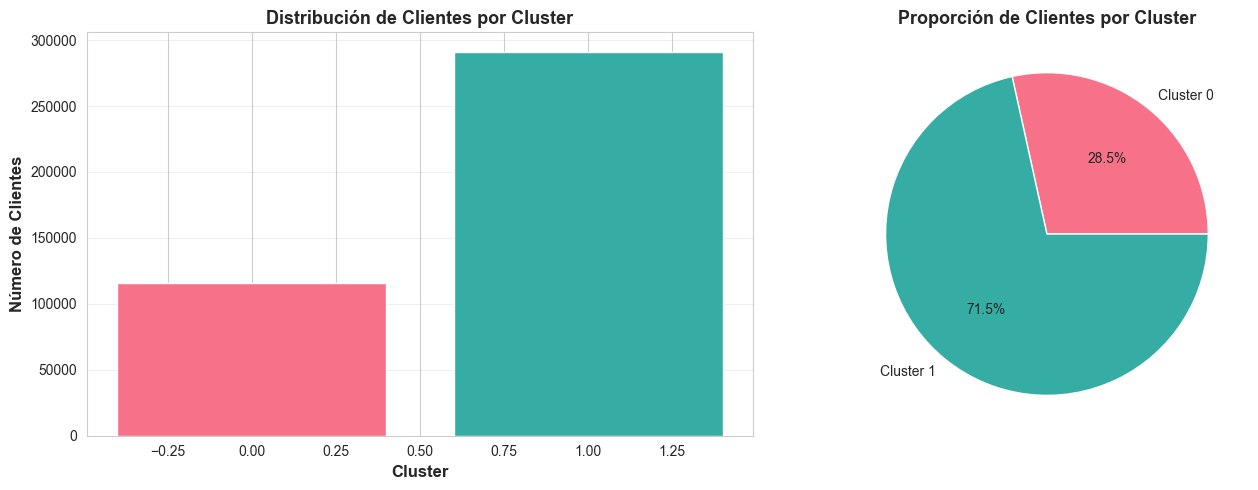

In [7]:
# Visualizar la distribución de clusters
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de barras
cluster_counts = pd.Series(clusters).value_counts().sort_index()
axes[0].bar(cluster_counts.index, cluster_counts.values, color=sns.color_palette("husl", optimal_k))
axes[0].set_xlabel('Cluster', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Número de Clientes', fontsize=12, fontweight='bold')
axes[0].set_title('Distribución de Clientes por Cluster', fontsize=13, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Gráfico de pastel
axes[1].pie(cluster_counts.values, labels=[f'Cluster {i}' for i in cluster_counts.index], 
            autopct='%1.1f%%', colors=sns.color_palette("husl", optimal_k))
axes[1].set_title('Proporción de Clientes por Cluster', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

In [8]:
# Análisis agregado por cluster

cluster_analysis = df.groupby('cluster').mean()

print("=" * 80)
print("ANÁLISIS DE SEGMENTOS - ESTADÍSTICAS PROMEDIO POR CLUSTER")
print("=" * 80)
print("\n", cluster_analysis)

# Guardar en formato más legible
print("\n\n" + "=" * 80)
print("CARACTERIZACIÓN DETALLADA DE SEGMENTOS")
print("=" * 80)

for cluster_id in range(optimal_k):
    cluster_data = df[df['cluster'] == cluster_id]
    
    print(f"\n{'='*80}")
    print(f"CLUSTER {cluster_id} ({len(cluster_data)} clientes - {(len(cluster_data)/len(df)*100):.2f}%)")
    print(f"{'='*80}")
    
    print(f"\nComportamiento de Compra:")
    print(f"  - Total de eventos promedio: {cluster_data['total_events'].mean():.2f}")
    print(f"  - Productos únicos visitados: {cluster_data['unique_products'].mean():.2f}")
    print(f"  - Adiciones al carrito: {cluster_data['cart'].mean():.2f}")
    print(f"  - Compras realizadas: {cluster_data['purchase'].mean():.2f}")
    print(f"  - Intensidad de interacción: {cluster_data['avg_events_per_product'].mean():.2f}")
    
    print(f"\nValor Económico:")
    print(f"  - Precio promedio visualizado: ${cluster_data['avg_price'].mean():.2f}")
    print(f"  - Precio promedio de compra: ${cluster_data['avg_purchase_price'].mean():.2f}")
    
    print(f"\nPatrones Temporales:")
    print(f"  - Recencia promedio: {cluster_data['recency_days'].mean():.1f} días")
    print(f"  - Actividad en la mañana: {cluster_data['pct_morning'].mean()*100:.2f}%")
    print(f"  - Actividad en la noche: {cluster_data['pct_evening'].mean()*100:.2f}%")
    
    print(f"\nPreferencias de Categoría:")
    print(f"  - Tecnología: {cluster_data['proportion_tech'].mean()*100:.2f}%")
    print(f"  - Fashion & Lifestyle: {cluster_data['proportion_fashion_lifestyle'].mean()*100:.2f}%")
    print(f"  - Home: {cluster_data['proportion_home'].mean()*100:.2f}%")

ANÁLISIS DE SEGMENTOS - ESTADÍSTICAS PROMEDIO POR CLUSTER

               user_id  total_events  unique_products      view      cart  \
cluster                                                                    
0        1.515916e+18      1.813498         1.231576  1.679189  0.074980   
1        1.515916e+18      2.313905         1.420680  2.053717  0.155612   

         purchase   avg_price  avg_events_per_product  avg_purchase_price  \
cluster                                                                     
0        0.059329   97.243544                1.447339            2.584229   
1        0.104575  142.023058                1.533804            8.975382   

         weighted_score  ...  pct_morning  pct_afternoon  pct_evening  \
cluster                  ...                                            
0              2.007136  ...      0.34687       0.336777     0.200603   
1              2.678668  ...      0.33153       0.339948     0.212809   

         pct_night  pct_weekday  

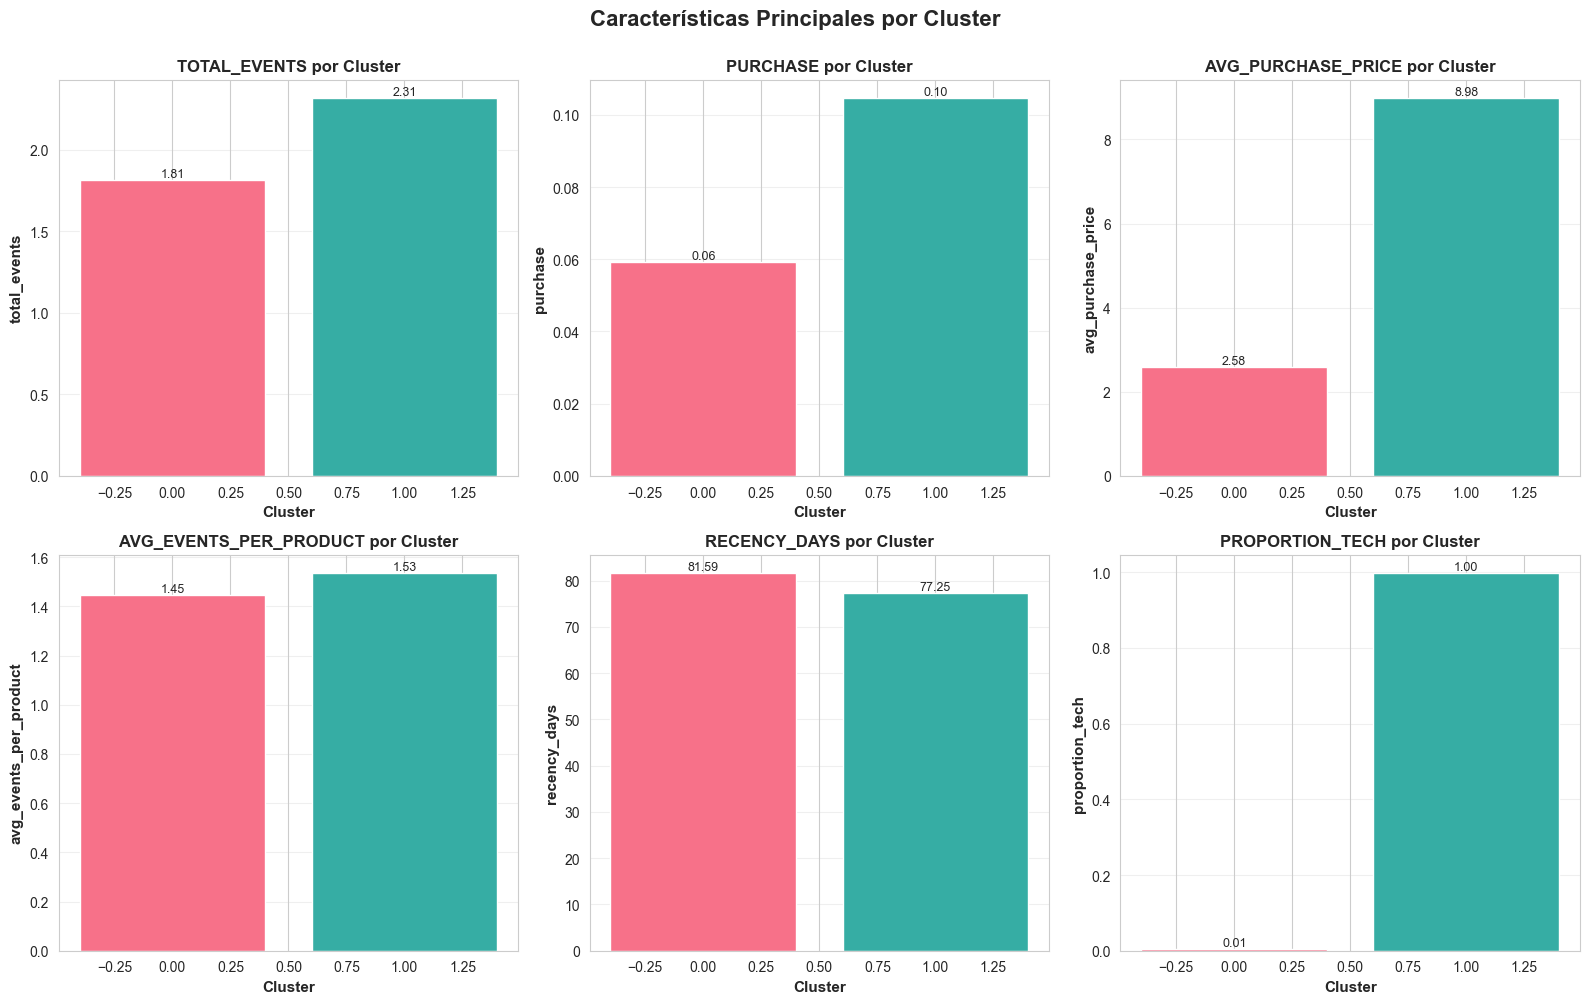

In [9]:
# Visualizaciones de características por cluster
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Características Principales por Cluster', fontsize=16, fontweight='bold', y=1.00)

metrics = [
    'total_events',
    'purchase',
    'avg_purchase_price',
    'avg_events_per_product',
    'recency_days',
    'proportion_tech'
]

# Visualizar cada métrica por cluster
for idx, metric in enumerate(metrics):
    ax = axes[idx // 3, idx % 3]
    cluster_means = df.groupby('cluster')[metric].mean()
    colors = sns.color_palette("husl", optimal_k)
    
    bars = ax.bar(cluster_means.index, cluster_means.values, color=colors)
    ax.set_xlabel('Cluster', fontsize=11, fontweight='bold')
    ax.set_ylabel(metric, fontsize=11, fontweight='bold')
    ax.set_title(f'{metric.upper()} por Cluster', fontsize=12, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    
    # Añadir valores en las barras
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

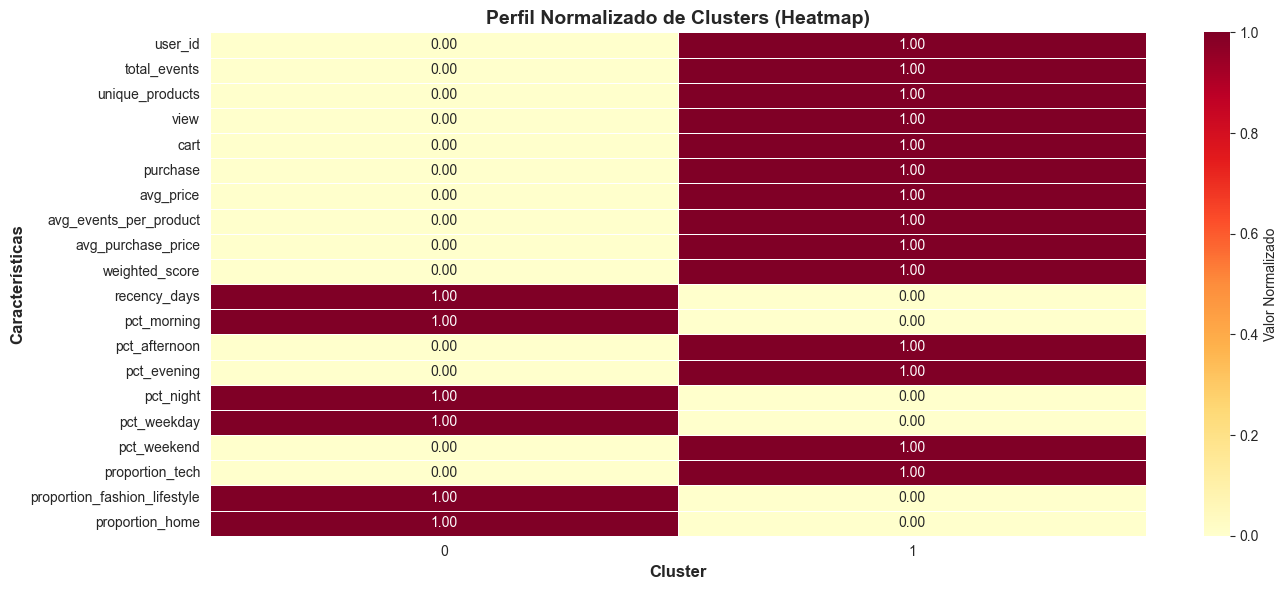

In [10]:
# Heatmap de características por cluster (datos normalizados para visualización)
cluster_profiles = df.groupby('cluster').mean().iloc[:, :-1]  # Excluir la columna de cluster si existe
cluster_profiles_normalized = (cluster_profiles - cluster_profiles.min()) / (cluster_profiles.max() - cluster_profiles.min())

plt.figure(figsize=(14, 6))
sns.heatmap(cluster_profiles_normalized.T, annot=True, fmt='.2f', cmap='YlOrRd', 
            cbar_kws={'label': 'Valor Normalizado'}, linewidths=0.5)
plt.title('Perfil Normalizado de Clusters (Heatmap)', fontsize=14, fontweight='bold')
plt.xlabel('Cluster', fontsize=12, fontweight='bold')
plt.ylabel('Características', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Visualización con PCA (Análisis de Componentes Principales)

In [11]:
from sklearn.decomposition import PCA

# ============================================================
# REDUCCIÓN DE DIMENSIONALIDAD CON PCA
# ============================================================

pca = PCA(
    n_components=2,
    random_state=42
)

# Transformar datos escalados
df_pca = pca.fit_transform(df_scaled)

# ============================================================
# VARIANZA EXPLICADA
# ============================================================

print("=" * 80)
print("ANÁLISIS PCA")
print("=" * 80)

print(f"Varianza explicada por PC1: {pca.explained_variance_ratio_[0]*100:.2f}%")

print(f"Varianza explicada por PC2: {pca.explained_variance_ratio_[1]*100:.2f}%")

print(f"Varianza acumulada: {sum(pca.explained_variance_ratio_)*100:.2f}%")

ANÁLISIS PCA
Varianza explicada por PC1: 23.46%
Varianza explicada por PC2: 14.72%
Varianza acumulada: 38.18%


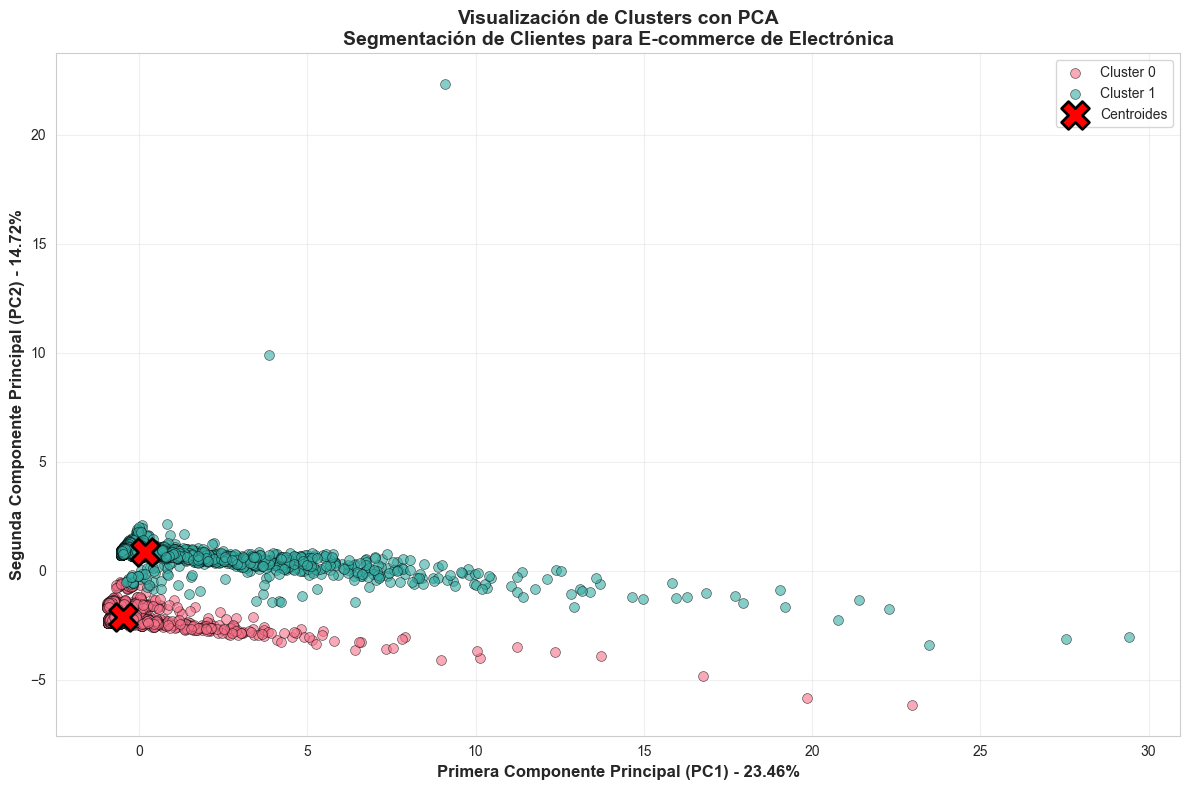

In [12]:
# Visualización en 2D con PCA - Scatter plot de clusters

# ============================================================
# MUESTRA PARA VISUALIZACIÓN
# ============================================================

sample_size = 10000

sample_idx = np.random.choice(
    len(df_pca),
    sample_size,
    replace=False
)

df_pca_sample = df_pca[sample_idx]

clusters_sample = clusters[sample_idx]

plt.figure(figsize=(12, 8))

# Colores para cada cluster
colors = sns.color_palette("husl", optimal_k)
cluster_names = [f'Cluster {i}' for i in range(optimal_k)]

# Graficar cada cluster
for cluster_id in range(optimal_k):
    mask = clusters_sample == cluster_id
    plt.scatter(df_pca_sample[mask, 0], df_pca_sample[mask, 1], 
               label=cluster_names[cluster_id],
               alpha=0.6, s=50, color=colors[cluster_id], edgecolors='k', linewidth=0.5)

# Graficar los centroides en el espacio PCA
centroids_pca = pca.transform(kmeans_final.cluster_centers_)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], 
           marker='X', s=400, c='red', edgecolors='black', linewidth=2,
           label='Centroides', zorder=5)

plt.xlabel(f'Primera Componente Principal (PC1) - {pca.explained_variance_ratio_[0]*100:.2f}%', 
          fontsize=12, fontweight='bold')
plt.ylabel(f'Segunda Componente Principal (PC2) - {pca.explained_variance_ratio_[1]*100:.2f}%', 
          fontsize=12, fontweight='bold')
plt.title('Visualización de Clusters con PCA\nSegmentación de Clientes para E-commerce de Electrónica', 
         fontsize=14, fontweight='bold')
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

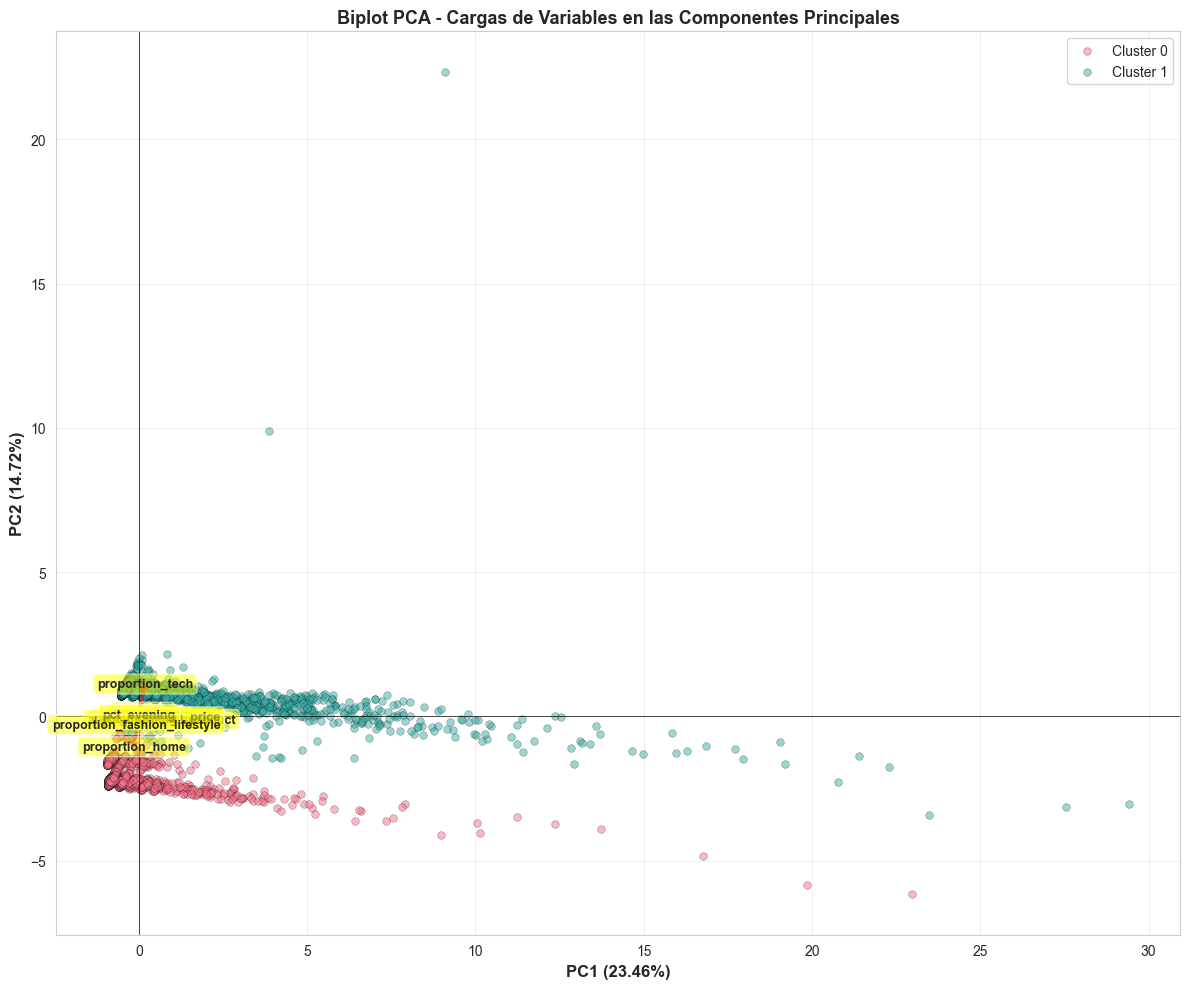

In [13]:
# Biplot - Visualización de las cargas de PCA (loading vectors)
pca_2d = PCA(n_components=2, random_state=42)
pca_2d.fit(df_scaled)

fig, ax = plt.subplots(figsize=(12, 10))

# Scatter plot de datos
colors = sns.color_palette("husl", optimal_k)
for cluster_id in range(optimal_k):
    mask = clusters_sample == cluster_id
    ax.scatter(df_pca_sample[mask, 0], df_pca_sample[mask, 1], 
              alpha=0.5, s=30, color=colors[cluster_id], 
              label=f'Cluster {cluster_id}', edgecolors='k', linewidth=0.3)

# Añadir loading vectors (flechas que representan las variables originales)
loadings = pca_2d.components_.T * np.sqrt(pca_2d.explained_variance_)
feature_names = df_scaled.columns

for i, feature in enumerate(feature_names):
    ax.arrow(0, 0, loadings[i, 0], loadings[i, 1],
            head_width=0.15, head_length=0.15, fc='red', ec='red', alpha=0.6, linewidth=2)
    ax.text(loadings[i, 0]*1.15, loadings[i, 1]*1.15, feature, 
           fontsize=9, ha='center', va='center', fontweight='bold',
           bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.5))

ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.2f}%)', 
             fontsize=12, fontweight='bold')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.2f}%)', 
             fontsize=12, fontweight='bold')
ax.set_title('Biplot PCA - Cargas de Variables en las Componentes Principales', 
            fontsize=13, fontweight='bold')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='k', linestyle='-', linewidth=0.5)
ax.axvline(x=0, color='k', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.show()

## 8. Conclusiones e Interpretación Estratégica

In [14]:
# INTERPRETACIÓN Y ANÁLISIS ESTRATÉGICO DE SEGMENTOS
print("=" * 100)
print("ANÁLISIS ESTRATÉGICO DE SEGMENTOS PARA PERSONALIZACIÓN EN E-COMMERCE DE ELECTRÓNICA")
print("=" * 100)

# Crear perfiles de segmentos basados en características clave
segment_profiles = {}

for cluster_id in range(optimal_k):
    cluster_data = df[df['cluster'] == cluster_id]
    
    # Calcular métricas clave
    avg_purchase_price = cluster_data['avg_purchase_price'].mean()
    avg_recency = cluster_data['recency_days'].mean()
    total_events = cluster_data['total_events'].mean()
    purchase_count = cluster_data['purchase'].mean()
    interaction_intensity = cluster_data['avg_events_per_product'].mean()
    tech_preference = cluster_data['proportion_tech'].mean()
    
    # Determinar el tipo de cliente basado en el comportamiento
    if (
        purchase_count > df['purchase'].quantile(0.75)
        and avg_purchase_price > df['avg_purchase_price'].quantile(0.75)
    ):

        profile = "🌟 HIGH-VALUE BUYER"
        strategy = "Productos premium + cross-selling inteligente"

    elif (
        total_events > df['total_events'].quantile(0.75)
        and interaction_intensity > df['avg_events_per_product'].quantile(0.75)
    ):

        profile = "🔍 HIGHLY ENGAGED USER"
        strategy = "Contenido técnico + recomendaciones avanzadas"

    elif avg_recency > df['recency_days'].quantile(0.75):

        profile = "⏰ DORMANT USER"
        strategy = "Campañas de reactivación + ofertas especiales"

    elif tech_preference > 0.70:

        profile = "💻 TECH-FOCUSED CUSTOMER"
        strategy = "Recomendaciones de electrónica y gadgets"

    else:

        profile = "🌱 CASUAL BROWSER"
        strategy = "Onboarding + incentivos de primera compra"
        

    # GUARDAR PERFIL
    segment_profiles[cluster_id] = {
        'profile': profile,
        'strategy': strategy,
        'purchase_price': avg_purchase_price,
        'recency': avg_recency,
        'events': total_events,
        'purchase_count': purchase_count,
        'interaction': interaction_intensity,
        'tech_pref': tech_preference
    }
        

# Imprimir análisis estratégico
for cluster_id in range(optimal_k):
    profile_info = segment_profiles[cluster_id]
    cluster_data = df[df['cluster'] == cluster_id]
    
    print(f"\n{'='*100}")
    print(f"SEGMENTO {cluster_id}: {profile_info['profile']}")
    print(f"{'='*100}")
    print(f"Tamaño: {len(cluster_data)} clientes ({len(cluster_data)/len(df)*100:.1f}% de la base)")
    print(f"\n📊 MÉTRICAS CLAVE:")
    print(f"  • Total de eventos: {profile_info['events']:.2f}")
    print(f"  • Compras promedio: {profile_info['purchase_count']:.2f}")
    print(f"  • Productos únicos visitados: {cluster_data['unique_products'].mean():.2f}")
    print(f"  • Intensidad de interacción: {profile_info['interaction']:.2f}")
    print(f"  • Precio promedio de compra: ${profile_info['purchase_price']:.2f}")
    print(f"  • Recencia promedio: {profile_info['recency']:.1f} días")
    print(f"  • Afinidad tecnológica: {profile_info['tech_pref']*100:.2f}%")
    
    print(f"\n🎯 ESTRATEGIA DE PERSONALIZACIÓN:")
    print(f"  {profile_info['strategy']}")
    
    print(f"\n💡 RECOMENDACIONES ESPECÍFICAS:")
    if 'HIGH-VALUE' in profile_info['profile']:
        print(f"  1. Crear programa de fidelización exclusivo con beneficios premium")
        print(f"  2. Ofrecer acceso temprano a productos nuevos y ediciones limitadas")
        print(f"  3. Proporcionar atención al cliente personalizada y soporte VIP")
        print(f"  4. Recomendaciones basadas en IA de productos complementarios de alta gama")
    elif 'ACTIVE CONVERTER' in profile_info['profile']:
        print(f"  1. Implementar recomendaciones de productos relacionados en la página de checkout")
        print(f"  2. Crear campañas de upsell/cross-sell personalizadas por email")
        print(f"  3. Ofrecer descuentos progresivos para compras múltiples")
        print(f"  4. Proporcionar garantías extendidas en productos de interés")
    elif 'RESEARCH-ORIENTED' in profile_info['profile']:
        print(f"  1. Crear guías de comparación técnica entre productos")
        print(f"  2. Proporcionar especificaciones detalladas y videos técnicos")
        print(f"  3. Implementar testimonios de expertos y reviews técnicas")
        print(f"  4. Ofrecer webinars educativos sobre tecnologías de productos")
    elif 'DORMANT' in profile_info['profile']:
        print(f"  1. Campaña de reactivación con descuentos exclusivos por tiempo limitado")
        print(f"  2. Enviar emails personalizados mostrando nuevos productos de su interés")
        print(f"  3. Ofrecer envío gratis en la próxima compra")
        print(f"  4. Realizar seguimiento con notificaciones de ofertas flash")
    else:
        print(f"  1. Crear experiencia de onboarding mejorada para nuevos visitantes")
        print(f"  2. Implementar recomendaciones no intrusivas basadas en comportamiento")
        print(f"  3. Ofrecer incentivos de primera compra (descuentos, cupones)")
        print(f"  4. Simplificar el proceso de compra con opciones de pago variadas")

print(f"\n{'='*100}")
print("CONCLUSIONES GENERALES")
print(f"{'='*100}")

sample_size = 10000

sample_idx = np.random.choice(
    len(df_scaled),
    sample_size,
    replace=False
)

df_scaled_sample = df_scaled.iloc[sample_idx]

clusters_sample = clusters[sample_idx]

sil_score = silhouette_score(
    df_scaled_sample,
    clusters_sample
)

print(f"\n✓ El modelo K-Means identificó {optimal_k} segmentos de clientes distintos")
print(f"✓ El Silhouette Score de {sil_score:.4f} indica una buena separación entre clusters")
print(f"✓ PCA redujo {df_scaled.shape[1]} dimensiones a 2, explicando {sum(pca.explained_variance_ratio_)*100:.2f}% de la varianza")
print(f"✓ Estos segmentos pueden usarse para personalizar recomendaciones y mejorar la experiencia del cliente")

ANÁLISIS ESTRATÉGICO DE SEGMENTOS PARA PERSONALIZACIÓN EN E-COMMERCE DE ELECTRÓNICA

SEGMENTO 0: 🌟 HIGH-VALUE BUYER
Tamaño: 115897 clientes (28.5% de la base)

📊 MÉTRICAS CLAVE:
  • Total de eventos: 1.81
  • Compras promedio: 0.06
  • Productos únicos visitados: 1.23
  • Intensidad de interacción: 1.45
  • Precio promedio de compra: $2.58
  • Recencia promedio: 81.6 días
  • Afinidad tecnológica: 0.53%

🎯 ESTRATEGIA DE PERSONALIZACIÓN:
  Productos premium + cross-selling inteligente

💡 RECOMENDACIONES ESPECÍFICAS:
  1. Crear programa de fidelización exclusivo con beneficios premium
  2. Ofrecer acceso temprano a productos nuevos y ediciones limitadas
  3. Proporcionar atención al cliente personalizada y soporte VIP
  4. Recomendaciones basadas en IA de productos complementarios de alta gama

SEGMENTO 1: 🌟 HIGH-VALUE BUYER
Tamaño: 291340 clientes (71.5% de la base)

📊 MÉTRICAS CLAVE:
  • Total de eventos: 2.31
  • Compras promedio: 0.10
  • Productos únicos visitados: 1.42
  • Intensid


✓ El modelo K-Means identificó 2 segmentos de clientes distintos
✓ El Silhouette Score de 0.3082 indica una buena separación entre clusters
✓ PCA redujo 13 dimensiones a 2, explicando 38.18% de la varianza
✓ Estos segmentos pueden usarse para personalizar recomendaciones y mejorar la experiencia del cliente
